# LFM DINO vs Graha Semantic Segmentation Comparison Workflow

## Purpose of this notebook
This notebook compares the existing toy DINO semantic segmentation model against the Graha/Lunar-FM semantic segmentation model on the same split-folder data. It runs the two models sequentially to limit VRAM/RAM pressure: first DINO with the toy DINO datamodule, then Graha with the Graha datamodule, then it creates side-by-side plots from saved prediction caches.

## Imports and shared workflow helpers

In [1]:
import gc
import sys
from pathlib import Path

import torch

NOTEBOOK_DIR = Path.cwd().resolve()
LFM_ROOT = NOTEBOOK_DIR.parents[1]

SCRIPTS_PY_DIR = LFM_ROOT / "scripts" / "python"
for import_path in [SCRIPTS_PY_DIR, LFM_ROOT]:
    if str(import_path) not in sys.path:
        sys.path.insert(0, str(import_path))

print("Notebook directory:", NOTEBOOK_DIR)
print("LFM root:", LFM_ROOT)

Notebook directory: /panfs/ccds02/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/notebooks/full_model
LFM root: /panfs/ccds02/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm


In [2]:
from argparse import Namespace

from IPython.display import Image, display
from lightning.pytorch import seed_everything

from lfm.full_model import lfm_seg_finetuning_direct as graha_workflow
from lfm.full_model.utils import (
    create_timestamped_output_dir,
    evaluate_prediction_caches,
    plot_prediction_cache_comparison,
    save_prediction_cache,
)
from lfm.full_model.utils.utils import ensure_data_symlink
from toy_sem_seg_comparison import (
    build_config,
    create_datamodule,
    create_lightning_module,
    create_model,
    create_trainer,
    load_lightning_checkpoint_state,
    save_config,
    validate_data_paths,
)

## User Config

The config below controls both model runs. DINO-specific settings apply to the toy DINO workflow; Graha-specific settings apply to the Graha/Lunar-FM workflow. Both models read from the same `DATA_ROOT`/`./data` split folders.

#### Paths
`INPUT_ROOT_DIR`: optional source directory containing the split-folder dataset. If set, the notebook creates `./data` as a symlink to this directory.

`DATA_ROOT`: optional explicit data directory. Leave as `None` to use `./data`, matching the sbatch script default.

`OUTPUT_DIR`: output root for checkpoints, config snapshots, file lists, logs, and visualizations.

`DINO_CHECKPOINT`: optional local DinoV3 checkpoint path. Leave as `None` to use the default path in `sseg_model.py`.

`DINO_LIGHTNING_CHECKPOINT` and `GRAHA_LIGHTNING_CHECKPOINT`: optional Lightning `.ckpt` files. If fitting that model, the trainer resumes from the checkpoint. If fitting is skipped for that model, the checkpoint weights are loaded before prediction caching.

#### Dataset parameters
`BAND_FILTER`: list of input bands to keep, in order.

`TARGET_SIZE` and `SPATIAL_TRANSFORM`: control whether the split data is resized or cropped before entering the toy model. The comparison baseline uses a 256x256 center crop to better match the Graha/full-model path.

`MAX_*_SAMPLES`: optional per-split sample limits for smoke tests.

#### Training hyperparameters
`BATCH_SIZE`, `NUM_EPOCHS`, `BASE_LR`, and `WEIGHT_DECAY` control the DINO training run.

#### Model hyperparameters
`FREEZE_ENCODER`: whether to keep the DinoV3 encoder frozen.

`LOSS_TYPE`: Lightning loss wrapper option for the DINO comparison run. Use `dice` for the tighter comparison because Graha also uses Dice as its primary loss.

`NORMALIZE_INPUTS`: enables DINO train-split z-score normalization after the same per-sample min-max/crop preprocessing used by the DINO dataset.

`DISABLE_TOY_GRADIENT_CLIPPING`: disables DINO gradient clipping so it matches the current Graha trainer path, which does not configure explicit gradient clipping.

#### Visualization
`PLOT_EVERY_N_EPOCHS` and `PLOT_N_SAMPLES` control validation prediction plots saved under the timestamped output directory.

#### Comparison cache
`CACHE_PREDICTIONS` saves lightweight prediction files for side-by-side comparison. The notebook runs and caches both the toy model and Graha/full model sequentially, then creates side-by-side plots from the saved caches.

In [3]:
# Data paths
INPUT_ROOT_DIR = None  # Example: Path("/explore/nobackup/projects/lfm/model_inputs/my_sem_seg_split")
DATA_ROOT = None  # Leave as None to use NOTEBOOK_DIR / "data"
OUTPUT_DIR = "./outputs/toy_sem_seg_comparison"
DINO_CHECKPOINT = None  # Leave as None to use the default checkpoint in sseg_model.py
DINO_LIGHTNING_CHECKPOINT = None
GRAHA_LIGHTNING_CHECKPOINT = None

# Symlink setup
SIMLINK_DEST = INPUT_ROOT_DIR

# Dataset parameters
BAND_FILTER = [0, 1, 2, 3, 4, 5, 6]
TARGET_SIZE = 256
SPATIAL_TRANSFORM = "crop"  # "crop" or "resize"
MAX_TRAIN_SAMPLES = None
MAX_VAL_SAMPLES = None
MAX_TEST_SAMPLES = None

# Training hyperparameters
BATCH_SIZE = 16
NUM_WORKERS = 10
NUM_EPOCHS = 1  # Use 1 for smoke tests; set to 100 for comparison runs.
BASE_LR = 5e-5
WEIGHT_DECAY = 0.05
LOSS_TYPE = "dice"
NORMALIZE_INPUTS = True
TOY_GRADIENT_CLIP_VAL = 1.0
DISABLE_TOY_GRADIENT_CLIPPING = True

# Model parameters
FREEZE_ENCODER = False

# Runtime controls
PLOT_EVERY_N_EPOCHS = 1
PLOT_N_SAMPLES = 5
CACHE_PREDICTIONS = True
PREDICTION_SPLIT = "val"
PREDICTION_N_SAMPLES = 20
SEED = 42
NO_FIT = False
SKIP_DINO_FIT = False
SKIP_GRAHA_FIT = False

# Graha/full-model comparison settings
GRAHA_PRETRAIN_DIR = None
GRAHA_OUTPUT_DIR = None  # Uses output_dir so both models share one timestamped root.
GRAHA_CROP_SIZE = 256
GRAHA_STATS_BATCH_SIZE = 16
GRAHA_BATCH_SIZE = 16
GRAHA_NUM_WORKERS = 10
GRAHA_NUM_EPOCHS = NUM_EPOCHS
GRAHA_NO_FIT = NO_FIT or SKIP_GRAHA_FIT

In [4]:
DATA_SYMLINK = ensure_data_symlink(SIMLINK_DEST, NOTEBOOK_DIR / "data")

SIMLINK_DEST is None; leaving data symlink unchanged.


In [5]:
args = Namespace(
    data_root=DATA_ROOT,
    base_output_dir=OUTPUT_DIR,
    dino_checkpoint=DINO_CHECKPOINT,
    dino_lightning_checkpoint=DINO_LIGHTNING_CHECKPOINT,
    band_filter=BAND_FILTER,
    target_size=TARGET_SIZE,
    spatial_transform=SPATIAL_TRANSFORM,
    max_train_samples=MAX_TRAIN_SAMPLES,
    max_val_samples=MAX_VAL_SAMPLES,
    max_test_samples=MAX_TEST_SAMPLES,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    max_epochs=NUM_EPOCHS,
    learning_rate=BASE_LR,
    weight_decay=WEIGHT_DECAY,
    loss_type=LOSS_TYPE,
    freeze_encoder=FREEZE_ENCODER,
    normalize_inputs=NORMALIZE_INPUTS,
    toy_gradient_clip_val=TOY_GRADIENT_CLIP_VAL,
    disable_toy_gradient_clipping=DISABLE_TOY_GRADIENT_CLIPPING,
    plot_every_n_epochs=PLOT_EVERY_N_EPOCHS,
    plot_n_samples=PLOT_N_SAMPLES,
    cache_predictions=CACHE_PREDICTIONS,
    prediction_split=PREDICTION_SPLIT,
    prediction_n_samples=PREDICTION_N_SAMPLES,
    graha_base_output_dir=GRAHA_OUTPUT_DIR,
    graha_pretrain_dir=GRAHA_PRETRAIN_DIR,
    graha_lightning_checkpoint=GRAHA_LIGHTNING_CHECKPOINT,
    graha_stats_batch_size=GRAHA_STATS_BATCH_SIZE,
    graha_batch_size=GRAHA_BATCH_SIZE,
    graha_num_workers=GRAHA_NUM_WORKERS,
    seed=SEED,
    no_fit=NO_FIT,
    skip_dino_fit=SKIP_DINO_FIT,
    skip_graha_fit=SKIP_GRAHA_FIT,
)

config = build_config(args)
validate_data_paths(config)

print("Data root:", config.data_root)
print("Base output dir:", config.base_output_dir)
print("Band filter:", config.band_filter)
print("Target size:", config.target_size)
print("Spatial transform:", config.spatial_transform)
print("Max train/val/test samples:", config.max_train_samples, config.max_val_samples, config.max_test_samples)
print("Normalize inputs:", config.normalize_inputs)
print("Loss type:", config.loss_type)
print("Toy gradient clip:", config.toy_gradient_clip_val)
print("Plot every N epochs:", config.plot_every_n_epochs)
print("Plot N samples:", config.plot_n_samples)
print("Cache predictions:", config.cache_predictions)
print("Prediction split/samples:", config.prediction_split, config.prediction_n_samples)
print("Max epochs:", config.max_epochs)

Data root: /panfs/ccds02/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/notebooks/full_model/data
Base output dir: /panfs/ccds02/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/notebooks/full_model/outputs/toy_sem_seg_comparison
Band filter: [0, 1, 2, 3, 4, 5, 6]
Target size: (256, 256)
Spatial transform: crop
Max train/val/test samples: None None None
Normalize inputs: False
Loss type: focal_dice
Plot every N epochs: 1
Plot N samples: 5
Cache predictions: True
Prediction split/samples: val 20
Max epochs: 1


## Create DINO output directory

In [6]:
output_dir = create_timestamped_output_dir(config.base_output_dir)
save_config(config, output_dir)
print("Output dir:", output_dir)

Using output subdir: /panfs/ccds02/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/notebooks/full_model/outputs/toy_sem_seg_comparison/date_2026_07_16-time_10_40_41
Output dir: /panfs/ccds02/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/notebooks/full_model/outputs/toy_sem_seg_comparison/date_2026_07_16-time_10_40_41


## Create DINO datamodule

In [7]:
seed_everything(config.seed)
datamodule = create_datamodule(config, output_dir)

if datamodule.weight_assignments is None:
    raise RuntimeError("DataModule did not create weight assignments.")

print("Weight assignments:", datamodule.weight_assignments)

[rank: 0] Seed set to 42


Filtered inputs and mean/std to channels: [0, 1, 2, 3, 4, 5, 6]
Found 490 matched image-label pairs
Dataset configured for 7 channel(s)
Filtered inputs and mean/std to channels: [0, 1, 2, 3, 4, 5, 6]
Found 123 matched image-label pairs
Dataset configured for 7 channel(s)
Data sanity summary:
  data_root: /panfs/ccds02/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/notebooks/full_model/data
  target_size: (256, 256)
  spatial_transform: crop
  band_filter: [0, 1, 2, 3, 4, 5, 6]
  normalize_inputs: False
  weight_assignments: ['blue', 'green', '0.7*red+0.3*green', 'red', '0.95*red', 'red', 'red']
  train_samples: 490
  val_samples: 123
  test_samples: None
  sample_image_shape: (7, 256, 256)
  sample_mask_shape: (256, 256)
  sample_mask_values: [0, 1]
  sample_foreground_fraction: 0.31842041015625
  sample_image_path: /panfs/ccds02/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/notebooks/full_model/data/train/chips/M1096558039CE_r7650_c750_input_wac_static_chip.tif
  sample_lab

## Load DINO encoder and create DINO model

In [8]:
model = create_model(config, datamodule.weight_assignments)
task = create_lightning_module(config, model)

print(type(model))
print(type(task))

Loading model from /explore/nobackup/projects/lfm/model_weights/dinov3_vitl16_pretrain_sat493m-eadcf0ff.pth


Using cache found in /home/ajkerr1/.cache/torch/hub/facebookresearch_dinov3_main


Encoder loaded with pretrained weights.
Modifying input weights for 7 bands...
Applied flexible embedding approach: ['blue', 'green', '0.7*red+0.3*green', 'red', '0.95*red', 'red', 'red']
Encoder unfrozen! Full model will be trained.
<class 'lfm.toy_model.sem_seg.sseg_model.DINOSegmentation'>
<class 'lfm.toy_model.sem_seg.lightning_wrappers.toy_sem_seg_lightning.ToySemSegLightningModule'>


## Create DINO trainer

In [9]:
trainer = create_trainer(config, output_dir, plots_subdir=Path("plots") / "toy_model")

Creating Lightning trainer...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


## Train DINO model

In [10]:
# Set args.max_epochs = 1 in the config cell for a smoke test.
if config.skip_dino_fit:
    print("Skipping DINO trainer.fit().")
    if config.dino_lightning_checkpoint is not None:
        load_lightning_checkpoint_state(task, config.dino_lightning_checkpoint, "DINO")
else:
    dino_ckpt_path = str(config.dino_lightning_checkpoint) if config.dino_lightning_checkpoint is not None else None
    if dino_ckpt_path is not None:
        print(f"Resuming DINO trainer.fit() from {dino_ckpt_path}")
    trainer.fit(task, datamodule=datamodule, ckpt_path=dino_ckpt_path)

Epoch 0/0  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31/31 0:00:28 • 0:00:00 1.20it/s v_num: 0.000 train/loss_step: 0.475 
                                                                               val/loss: 0.571 val/f1: 0.411       
                                                                               train/loss_epoch: 0.540             

`Trainer.fit` stopped: `max_epochs=1` reached.


## Test DINO best checkpoint

In [11]:
print("Skipping DINO test before caching so comparison predictions use final weights, matching Graha.")

Testing ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/1 0:00:00 • 0:00:00 0.00it/s

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/accuracy       │    0.7653366327285767     │
│          test/f1          │    0.5764870047569275     │
│    test/gt_fg_fraction    │    0.2286224365234375     │
│         test/iou          │    0.40497487783432007    │
│         test/loss         │    0.4606662392616272     │
│      test/precision       │    0.4907194972038269     │
│   test/pred_fg_fraction   │    0.3254654109477997     │
│        test/recall        │     0.698585033416748     │
└───────────────────────────┴───────────────────────────┘

## DINO prediction cache and side-by-side comparison setup

The notebook saves lightweight prediction caches so DINO and Graha can be compared without loading both models at once.

## Cache DINO predictions

In [12]:
toy_prediction_cache = save_prediction_cache(
    task=task,
    datamodule=datamodule,
    output_dir=output_dir,
    model_name="toy",
    split=config.prediction_split,
    n_samples=config.prediction_n_samples,
)

Filtered inputs and mean/std to channels: [0, 1, 2, 3, 4, 5, 6]
Found 490 matched image-label pairs
Dataset configured for 7 channel(s)
Filtered inputs and mean/std to channels: [0, 1, 2, 3, 4, 5, 6]
Found 123 matched image-label pairs
Dataset configured for 7 channel(s)
Saved 20 prediction cache file(s) to /panfs/ccds02/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/notebooks/full_model/outputs/toy_sem_seg_comparison/date_2026_07_16-time_10_40_41/prediction_cache/toy/val


## Release DINO model memory

In [13]:
del trainer, task, model, datamodule
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
print("Released toy model objects and cleared CUDA cache.")

Released toy model objects and cleared CUDA cache.


## Run Graha model and cache predictions

This section builds the Graha/Lunar-FM datamodule, computes Graha training statistics, creates the Graha task/model, trains it, and saves a Graha prediction cache.

In [14]:
graha_workflow.configure_proj_environment()

graha_args = Namespace(
    data_root=DATA_ROOT,
    base_output_dir=str(output_dir) if GRAHA_OUTPUT_DIR is None else GRAHA_OUTPUT_DIR,
    pretrain_dir=GRAHA_PRETRAIN_DIR,
    lightning_checkpoint=GRAHA_LIGHTNING_CHECKPOINT,
    crop_size=GRAHA_CROP_SIZE,
    stats_batch_size=GRAHA_STATS_BATCH_SIZE,
    batch_size=GRAHA_BATCH_SIZE,
    num_workers=GRAHA_NUM_WORKERS,
    max_epochs=GRAHA_NUM_EPOCHS,
    cache_predictions=True,
    prediction_split=PREDICTION_SPLIT,
    prediction_n_samples=PREDICTION_N_SAMPLES,
    seed=SEED,
    no_fit=GRAHA_NO_FIT,
)

graha_config = graha_workflow.build_config(graha_args)
graha_workflow.configure_python_paths(graha_config)
graha_workflow.print_config(graha_config)
graha_workflow.validate_required_paths(graha_config)

PROJ_DATA = /home/ajkerr1/.conda/envs/graha-lunar-fm/share/proj
GDAL_DATA = /home/ajkerr1/.conda/envs/graha-lunar-fm/share/gdal
Package directory: /panfs/ccds02/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/lfm/full_model
Notebook directory: /panfs/ccds02/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/notebooks/full_model
Graha/Lunar-FM code root: /panfs/ccds02/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/lfm/full_model/graha-lunar-fm
Data root: /panfs/ccds02/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/notebooks/full_model/data
Backbone weights: /panfs/ccds02/nobackup/projects/lfm/gabby/Lunar-FM/experiments/lunarfm_base_dual_full_nas_no_nans_256_256_lr1e-4_wd0.05/checkpoints/checkpoint_weights_final.pt
Backbone config: /panfs/ccds02/nobackup/projects/lfm/gabby/Lunar-FM/experiments/lunarfm_base_dual_full_nas_no_nans_256_256_lr1e-4_wd0.05/full_config.yaml
Modality info: /panfs/ccds02/nobackup/projects/lfm/gabby/Lunar-FM/experiments/lunarfm_base_dual_full_nas_no_

In [15]:
graha_deps = graha_workflow.import_project_dependencies()
graha_datamodule_cls = graha_deps["LunarSemanticSegmentationDatamodule"]
graha_task_cls = graha_workflow.make_notebook_task_class(
    graha_deps["LunarShapeSegmentationTask"]
)

graha_output_dir = graha_workflow.create_output_dirs(
    graha_config,
    graha_deps["create_timestamped_output_dir"],
    use_timestamp=False,
)
seed_everything(graha_config.seed)

graha_means, graha_stds = graha_workflow.calculate_train_stats(
    graha_config,
    graha_datamodule_cls,
)
graha_datamodule = graha_workflow.create_datamodule(
    graha_config,
    graha_datamodule_cls,
    graha_means,
    graha_stds,
)
graha_sample_batch = graha_workflow.inspect_batch(graha_datamodule)
graha_task = graha_workflow.create_task(
    graha_config,
    graha_task_cls,
    graha_sample_batch,
)
graha_workflow.inspect_backbone(graha_task)
graha_trainer = graha_workflow.create_trainer(
    graha_config,
    graha_output_dir,
    graha_deps["ValidationPlotCallback"],
    plot_output_dir=output_dir,
    plots_subdir=Path("plots") / "full_model",
    checkpoint_subdir=Path("checkpoints") / "full_model",
)

[rank: 0] Seed set to 42


Using output subdir: /panfs/ccds02/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/notebooks/full_model/outputs/graha_finetuning/date_2026_07_16-time_10_43_00
Output directory: /panfs/ccds02/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/notebooks/full_model/outputs/graha_finetuning/date_2026_07_16-time_10_43_00
Plots directory: /panfs/ccds02/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/notebooks/full_model/outputs/graha_finetuning/date_2026_07_16-time_10_43_00/plots
per-band means: [0.023870304226875305, 0.03239678964018822, 0.0345771387219429, 0.036306023597717285, 0.03883824869990349, 0.015070014633238316, 0.017845287919044495]
per-band stds: [0.014905835501849651, 0.019833091646432877, 0.02095038630068302, 0.02188112959265709, 0.023320039734244347, 0.008971190080046654, 0.010731484740972519]
batch keys: dict_keys(['image', 'mask', 'filename'])
image: (16, 7, 256, 256) torch.float32
batch image per-band mean: [0.2652943432331085, 0.2787616550922394, 0.286524713039398

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


New modality embeddings (randomly initialized): 3 keys
encoder_embeddings.aspect.mod_emb
encoder_embeddings.aspect.pos_emb
encoder_embeddings.aspect.proj.weight
encoder_embeddings.aspect_3m.mod_emb
encoder_embeddings.aspect_3m.pos_emb
encoder_embeddings.aspect_3m.proj.weight
encoder_embeddings.dtm.mod_emb
encoder_embeddings.dtm.pos_emb
encoder_embeddings.dtm.proj.weight
encoder_embeddings.dtm_3m.mod_emb
encoder_embeddings.dtm_3m.pos_emb
encoder_embeddings.dtm_3m.proj.weight
encoder_embeddings.metadata.mod_emb
encoder_embeddings.metadata.pos_emb
encoder_embeddings.metadata.token_emb.weight
encoder_embeddings.nac.mod_emb
encoder_embeddings.nac.pos_emb
encoder_embeddings.nac.proj.weight
encoder_embeddings.slope.mod_emb
encoder_embeddings.slope.pos_emb
encoder_embeddings.slope.proj.weight
encoder_embeddings.slope_3m.mod_emb
encoder_embeddings.slope_3m.pos_emb
encoder_embeddings.slope_3m.proj.weight
encoder_embeddings.static_maps.mod_emb
encoder_embeddings.static_maps.pos_emb
encoder_embedd

In [16]:
if graha_args.no_fit:
    print("Skipping Graha trainer.fit() because GRAHA_NO_FIT is True.")
    if graha_config.lightning_checkpoint is not None:
        graha_workflow.load_lightning_checkpoint_state(graha_task, graha_config.lightning_checkpoint, "Graha")
else:
    graha_ckpt_path = str(graha_config.lightning_checkpoint) if graha_config.lightning_checkpoint is not None else None
    if graha_ckpt_path is not None:
        print(f"Resuming Graha trainer.fit() from {graha_ckpt_path}")
    graha_trainer.fit(graha_task, datamodule=graha_datamodule, ckpt_path=graha_ckpt_path)

graha_prediction_cache = save_prediction_cache(
    task=graha_task,
    datamodule=graha_datamodule,
    output_dir=graha_output_dir,
    model_name="graha",
    split=PREDICTION_SPLIT,
    n_samples=PREDICTION_N_SAMPLES,
)

Epoch 0/0  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31/31 0:00:38 • 0:00:00 0.82it/s v_num: 0.000

`Trainer.fit` stopped: `max_epochs=1` reached.


Saved 20 prediction cache file(s) to /panfs/ccds02/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/notebooks/full_model/outputs/graha_finetuning/date_2026_07_16-time_10_43_00/prediction_cache/graha/val


## Release Graha model memory

In [17]:
del graha_trainer, graha_task, graha_datamodule, graha_sample_batch
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
print("Released Graha model objects and cleared CUDA cache.")

Released Graha model objects and cleared CUDA cache.


## Create side-by-side DINO vs Graha plots

This cell compares the DINO and Graha prediction caches generated above. It does not reload either model.

Saved side-by-side comparison plot to /panfs/ccds02/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/notebooks/full_model/outputs/toy_sem_seg_comparison/date_2026_07_16-time_10_40_41/comparison_plots/side_by_side_predictions.png


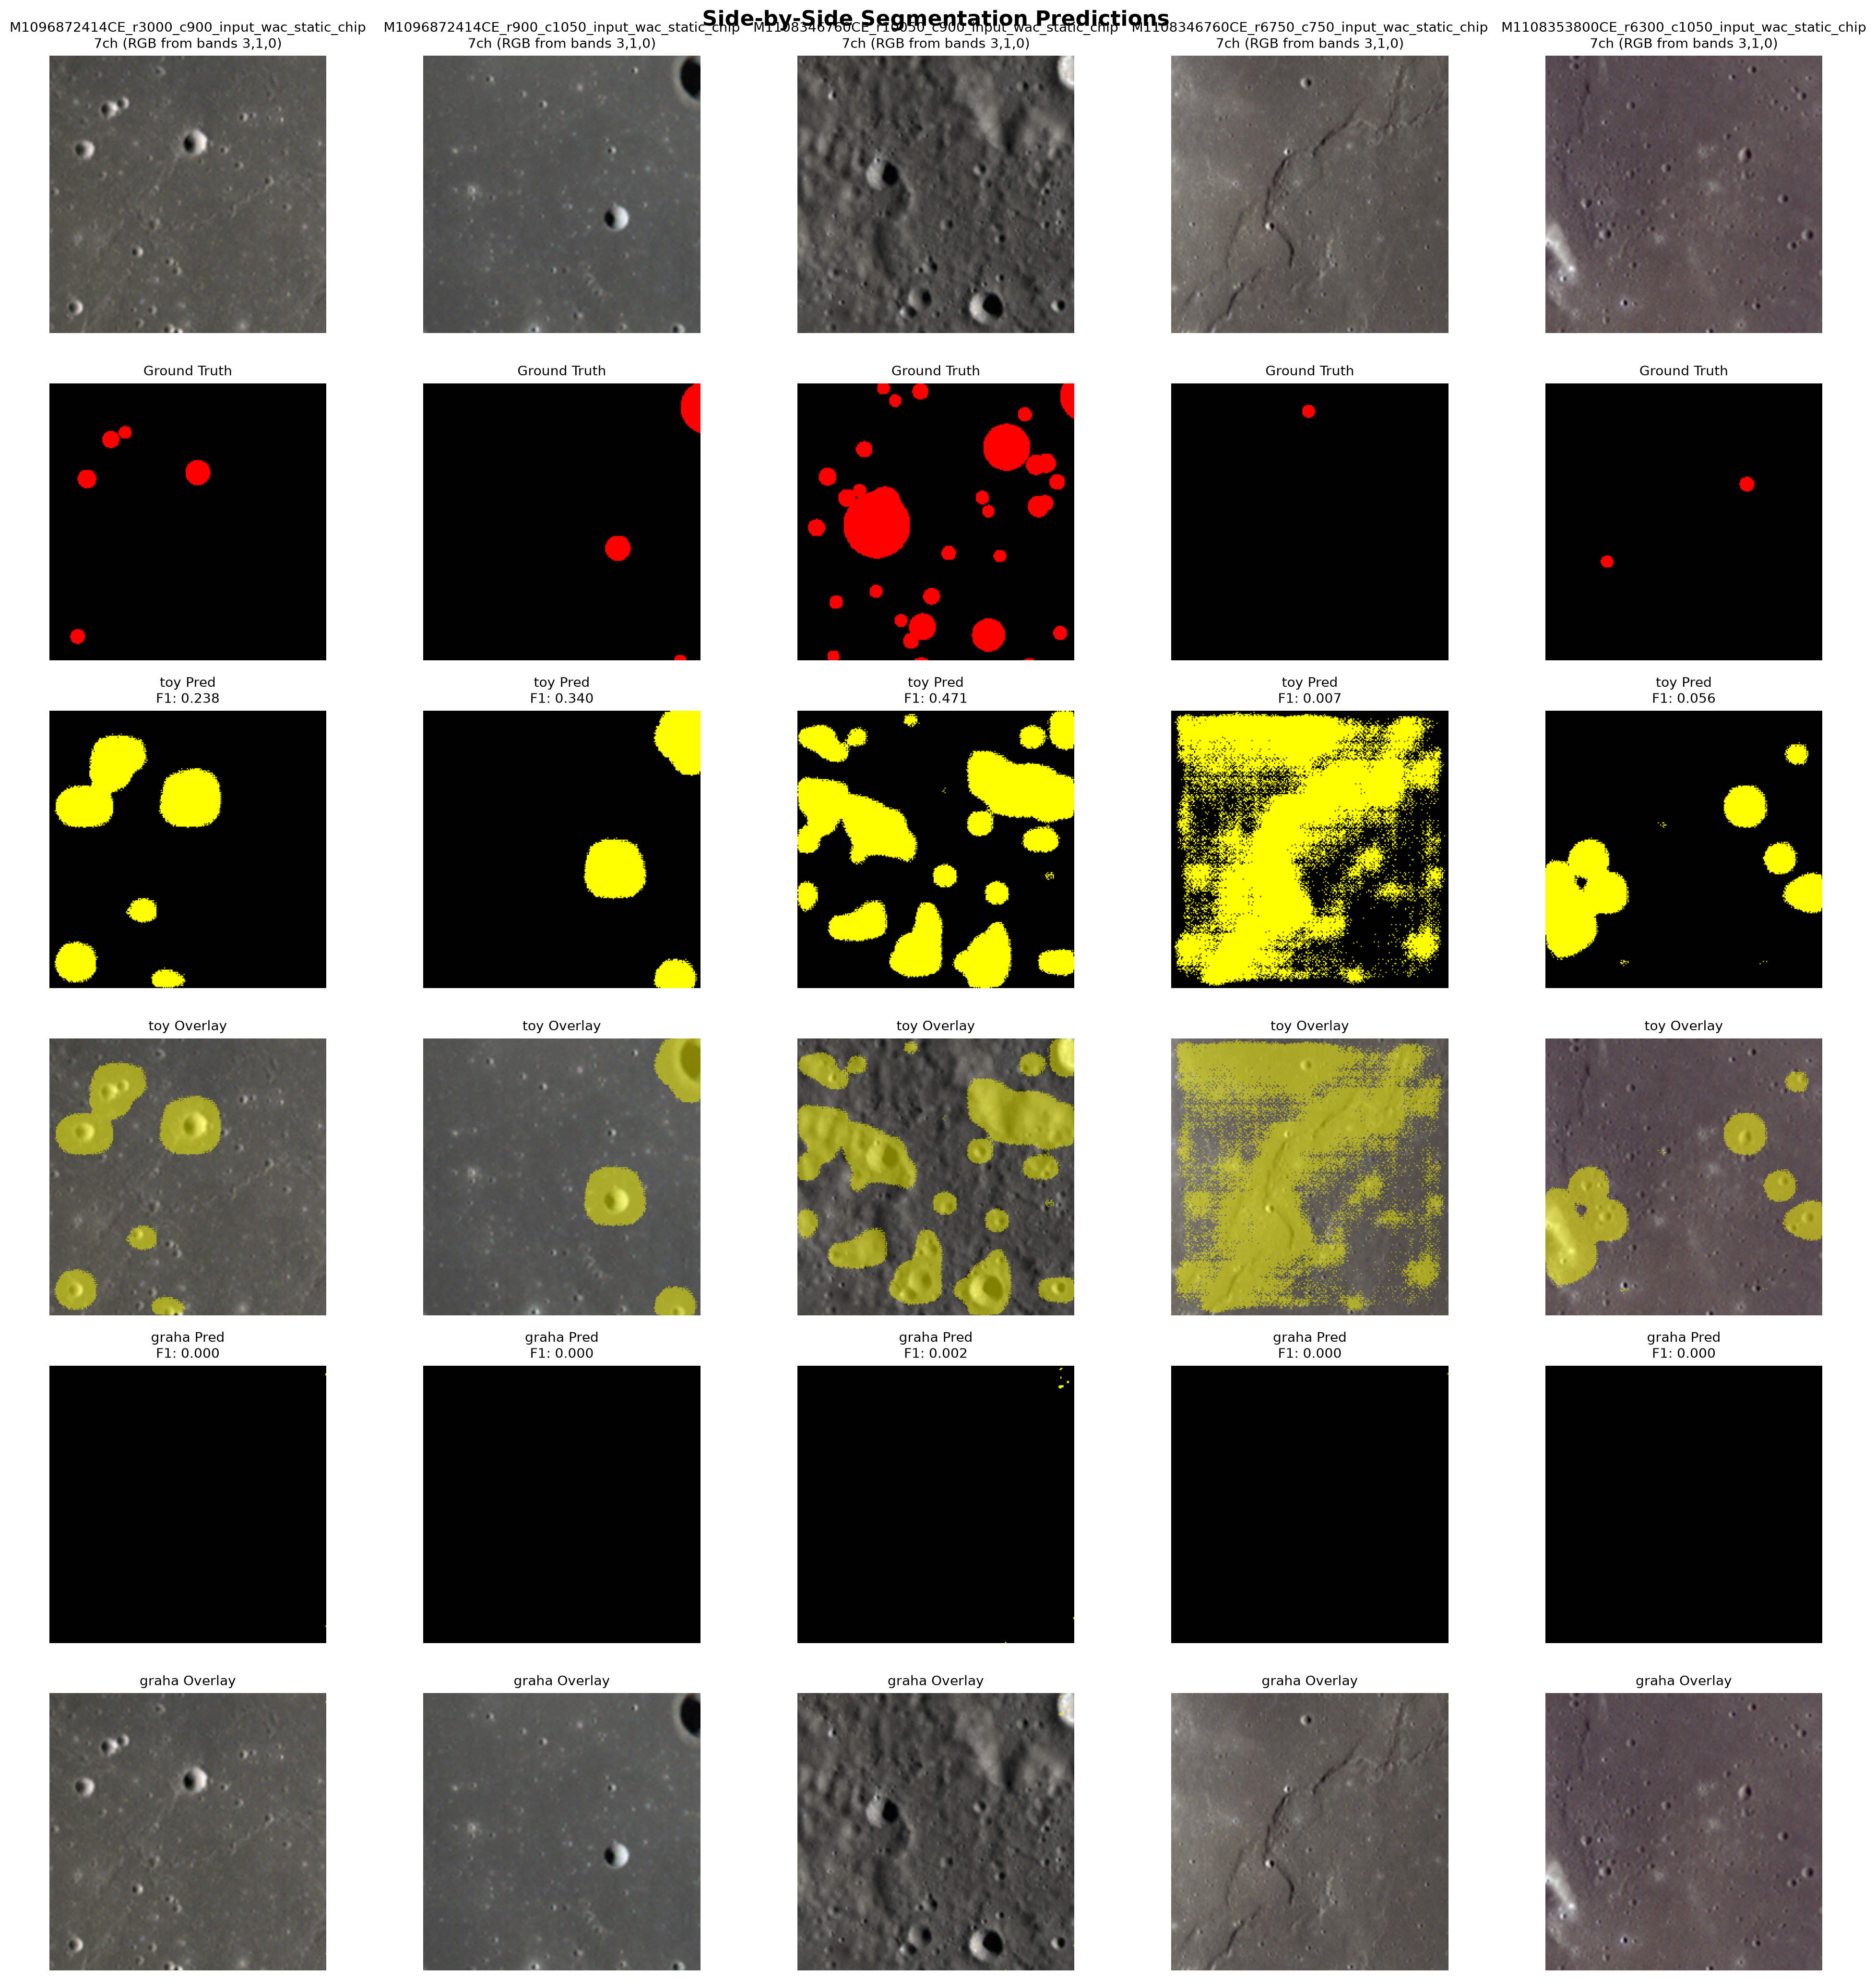

In [18]:
comparison_caches = {}
comparison_caches["toy"] = toy_prediction_cache
comparison_caches["graha"] = graha_prediction_cache

side_by_side_path = plot_prediction_cache_comparison(
    comparison_caches,
    output_dir / "comparison_plots",
    n_samples=5,
)
display(Image(filename=str(side_by_side_path)))

## Evaluate DINO vs Graha cached predictions

This section computes shared binary segmentation metrics from the cached DINO and Graha predictions and saves both per-sample and summary metric files.

In [ ]:
metric_rows, metric_summary = evaluate_prediction_caches(
    comparison_caches,
    output_dir / "comparison_metrics",
)
metric_summary

In [ ]:
try:
    import pandas as pd

    display(pd.DataFrame(metric_summary))
except ImportError:
    metric_summary